<a href="https://colab.research.google.com/github/AishwaryaGhorpade/Data-Science/blob/main/Machine_Learning/Multilinear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
#read data file
df=pd.read_csv("/content/50_Startups_dataset.csv")

In [43]:
df.head()

,Unnamed: 0,R&D Spend,Administration,Marketing Spend,State,Profit
0,0,165349.30,136897.90,471784.20,New York,192261.93
1,1,162597.80,151377.69,443898.63,California,191792.16
2,2,153441.61,101145.65,407934.64,Florida,191050.49
3,3,144372.51,118671.95,383199.72,New York,182902.09
4,4,142107.44,91391.87,366168.52,Florida,166188.04


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       50 non-null     int64  
 1   R&D Spend        50 non-null     float64
 2   Administration   50 non-null     float64
 3   Marketing Spend  50 non-null     float64
 4   State            50 non-null     object 
 5   Profit           50 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.5+ KB


In [45]:
df.describe()

,Unnamed: 0,R&D Spend,Administration,Marketing Spend,Profit
count,50.00000,50.000000,50.000000,50.000000,50.000000
mean,24.50000,73721.715600,121344.739600,211025.197800,112012.739200
std,14.57738,45902.256482,28017.802755,122290.310726,40306.180338
min,0.00000,0.100000,51283.240000,0.100000,14681.500000
25%,12.25000,39936.470000,103730.975000,129300.232500,90139.002500
50%,24.50000,73051.180000,122699.895000,212716.340000,107978.290000
75%,36.75000,101602.900000,144842.280000,299469.185000,139766.077500
max,49.00000,165349.300000,182645.660000,471784.200000,192261.930000


In [57]:
#Devide the data into dependent vs independents
X=df.iloc[:,1:-1].values
Y=df.iloc[:,-1].values

In [58]:
X

array([[165349.30000000002, 136897.9, 471784.2, 'New York'],
       [162597.80000000002, 151377.69, 443898.63, 'California'],
       [153441.61000000002, 101145.65, 407934.64, 'Florida'],
       [144372.51, 118671.95, 383199.72, 'New York'],
       [142107.44, 91391.87, 366168.52, 'Florida'],
       [131877.0, 99814.81, 362861.46, 'New York'],
       [134615.56, 147198.97, 127716.92, 'California'],
       [130298.23, 145530.16, 323876.78, 'Florida'],
       [120542.62, 148719.05000000002, 311613.39, 'New York'],
       [123334.98, 108679.27, 304981.72, 'California'],
       [101913.18, 110594.21, 229161.05, 'Florida'],
       [100672.06, 91790.71, 249744.65, 'California'],
       [93863.85, 127320.48, 249839.54, 'Florida'],
       [91992.49, 135495.17, 252665.03, 'California'],
       [119943.34, 156547.52000000002, 256513.02, 'Florida'],
       [114523.71, 122616.94, 261776.33, 'New York'],
       [78013.21, 121597.65, 264346.16, 'California'],
       [94657.26, 145077.68, 282574.41, 

In [59]:
Y

array([192261.93, 191792.16, 191050.49, 182902.09, 166188.04, 156991.22,
       156122.61, 155752.7 , 152211.87, 149760.06, 146122.05, 144259.5 ,
       141585.62, 134307.45, 132602.75, 129917.14, 126993.03, 125370.47,
       124267.  , 122776.96, 118474.13, 111313.12, 110352.35, 108734.09,
       108552.14, 107404.44, 105733.64, 105008.41, 103282.48, 101004.74,
        99937.69,  97483.66,  97427.94,  96779.02,  96712.9 ,  96479.61,
        90708.29,  89949.24,  81229.16,  81005.86,  78240.01,  77798.93,
        71498.59,  69759.08,  65200.43,  64926.18,  49490.85,  42559.83,
        35673.51,  14681.5 ])

In [61]:
#Feature Encoding - OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[3])],remainder='passthrough')
X=np.array(ct.fit_transform(X))

In [62]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)

In [63]:
len(X_train)

40

In [64]:
len(X_test)

10

In [65]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [66]:
#Create LR model
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train,Y_train)

LinearRegression()

In [67]:
#predictions
Y_pred=regressor.predict(X_test)

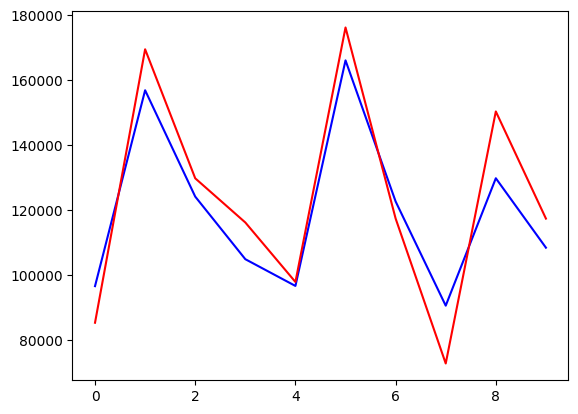

In [68]:
#ploting data Y_pred vs Y_test
plt.plot(Y_test,color='blue',label='Y_test')
plt.plot(Y_pred,color='red',label='prediction')
plt.show()